# FOXA2 Hepatocyte Epigenome Orientation

This notebook regenerates the thesis-facing TCGA-LIHC cohort and FOXA2 hepatocyte reference plots from curated files under `outputs/thesis/02_foxa2_epigenome_orientation`. It uses curated thesis-local inputs only. The reference terminology is standardised as `FOXA2+` and `FOXA2-`, where the plus/minus status refers to FOXA2 RNA detection in the single-cell hepatocyte reference populations.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name != 'mut-epi-origin':
    for parent in Path.cwd().parents:
        if parent.name == 'mut-epi-origin':
            ROOT = parent
            break

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
})


def save_and_show(fig: plt.Figure, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return path


THESIS_DIR = ROOT / 'outputs/thesis/02_foxa2_epigenome_orientation'
DATA_DIR = THESIS_DIR / 'data'
FIG_DIR = THESIS_DIR / 'figures'

lihc = pd.read_csv(DATA_DIR / 'primary_lihc_sample_table.csv')
clinical_summary = pd.read_csv(DATA_DIR / 'lihc_clinical_variable_plot_data.csv')
umap = pd.read_csv(DATA_DIR / 'gse281574_foxa2_umap_cells.csv')
atac_bins = pd.read_csv(DATA_DIR / 'foxa2_atac_500kb_bins.csv')
locus_summary = pd.read_csv(DATA_DIR / 'selected_locus_illustrative_sample_score_summary.csv')


## 1) TCGA-LIHC Mutation Burden

The clinically complete TCGA-LIHC subset contains 68 tumours. The median SNV burden is 10,898 mutations per sample, with an interquartile range of 7,291 to 14,266 and a range of 2,096 to 212,158.

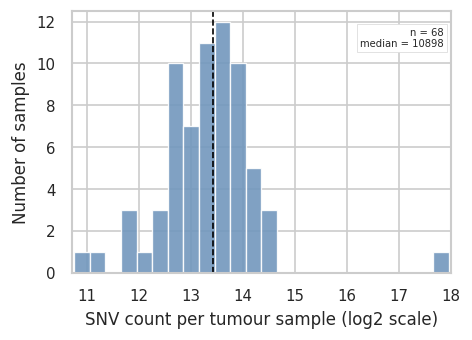

PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/02_foxa2_epigenome_orientation/figures/01_lihc_mutation_burden.png')

In [2]:
plot_df = lihc.copy()
log2_burden = np.log2(plot_df['snv_count'] + 1)
median_burden = int(plot_df['snv_count'].median())
median_log2 = np.log2(median_burden + 1)

fig, ax = plt.subplots(figsize=(4.1, 3.0))
bins = np.arange(10.75, 18.20, 0.30)
ax.hist(log2_burden, bins=bins, color='#7297bd', edgecolor='white', linewidth=0.8, alpha=0.9)
ax.axvline(median_log2, color='black', linestyle='--', linewidth=1.0)
ax.text(
    0.98,
    0.94,
    f'n = {len(plot_df)}\nmedian = {median_burden}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=6,
    bbox={'facecolor': 'white', 'edgecolor': '#dddddd', 'linewidth': 0.5, 'pad': 2},
)
ax.set_xlabel('SNV count per tumour sample (log2 scale)')
ax.set_ylabel('Number of samples')
ax.set_xlim(10.7, 18.0)
ax.set_ylim(0, 12.5)
ax.set_yticks(np.arange(0, 13, 2))
fig.tight_layout()
save_and_show(fig, FIG_DIR / '01_lihc_mutation_burden.png')


## 2) Clinicopathological Composition

This panel summarises the clinical annotations used for downstream association testing, including viral status, NAFLD, fibrosis, alcohol status and obesity class. These variables define the clinically complete subset used in the FOXA2 score association analyses.

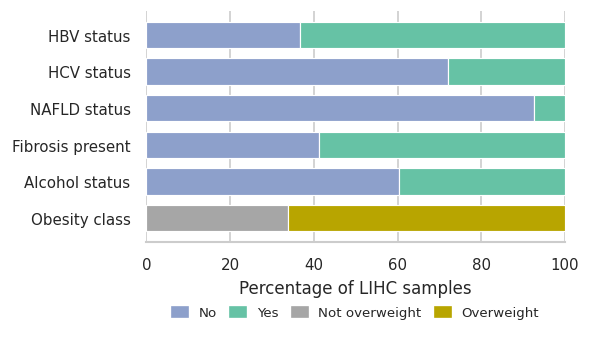

PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/02_foxa2_epigenome_orientation/figures/02_lihc_clinical_feature_summary.png')

In [3]:
plot_df = clinical_summary.copy()
var_order = ['HBV status', 'HCV status', 'NAFLD status', 'Fibrosis present', 'Alcohol status', 'Obesity class']
level_order = {
    'HBV status': ['No', 'Yes'],
    'HCV status': ['No', 'Yes'],
    'NAFLD status': ['No', 'Yes'],
    'Fibrosis present': ['No', 'Yes'],
    'Alcohol status': ['No', 'Yes'],
    'Obesity class': ['Not overweight', 'Overweight'],
}
colours = {
    'No': '#8da0cb',
    'Yes': '#66c2a5',
    'Not overweight': '#a6a6a6',
    'Overweight': '#b8a500',
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))
y_positions = np.arange(len(var_order))
for y, variable in zip(y_positions, var_order):
    left = 0.0
    sub = plot_df[plot_df['variable'] == variable].set_index('level')
    for level in level_order[variable]:
        value = float(sub.loc[level, 'percentage']) if level in sub.index else 0.0
        ax.barh(y, value, left=left, height=0.72, color=colours[level], edgecolor='white', linewidth=0.7)
        left += value

ax.set_yticks(y_positions)
ax.set_yticklabels(var_order)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage of LIHC samples')
ax.set_ylabel('')
handles = [plt.Rectangle((0, 0), 1, 1, color=colours[level]) for level in ['No', 'Yes', 'Not overweight', 'Overweight']]
ax.legend(handles, ['No', 'Yes', 'Not overweight', 'Overweight'], loc='upper center', bbox_to_anchor=(0.5, -0.23), ncol=4, frameon=False, columnspacing=1.0, handlelength=1.2)
sns.despine(ax=ax, left=True)
fig.subplots_adjust(bottom=0.28)
save_and_show(fig, FIG_DIR / '02_lihc_clinical_feature_summary.png')


## 3) FOXA2 Reference Cells

The FOXA2+ reference is derived from normal hepatocytes with FOXA2 RNA expression greater than zero. The FOXA2- reference is derived from diseased hepatocytes from alcohol-associated cirrhosis and alcohol-associated hepatitis samples with FOXA2 RNA expression equal to zero. These gates yield 733 FOXA2+ reference hepatocytes and 7,199 FOXA2- reference hepatocytes.

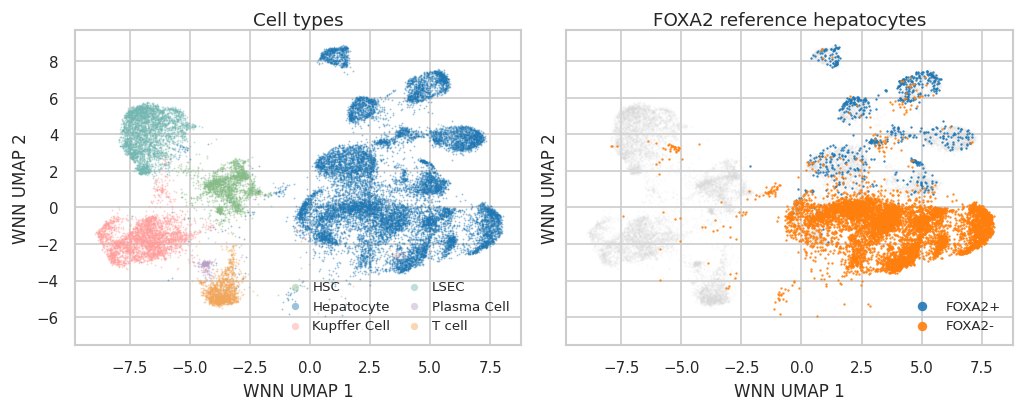

PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/02_foxa2_epigenome_orientation/figures/03_foxa2_umap_reference_cells.png')

In [4]:
plot_df = umap.copy()
celltype_order = ['HSC', 'Hepatocyte', 'Kupffer Cell', 'LSEC', 'Plasma Cell', 'T cell']
celltype_palette = {
    'HSC': '#86bc86',
    'Hepatocyte': '#1f77b4',
    'Kupffer Cell': '#ff9d9a',
    'LSEC': '#72b7b2',
    'Plasma Cell': '#b9a0c9',
    'T cell': '#f2a65a',
}
reference_palette = {'Other cells': '#d9d9d9', 'FOXA2+': '#1f77b4', 'FOXA2-': '#ff7f0e'}
plot_df['reference_label'] = plot_df['reference_group'].replace({
    'FOXA2+ reference cells': 'FOXA2+',
    'FOXA2- reference cells': 'FOXA2-',
    'Other cells': 'Other cells',
})

fig, axes = plt.subplots(1, 2, figsize=(8.7, 3.6), sharex=True, sharey=True)
shuffled = plot_df.sample(frac=1, random_state=1)
for cell_type in celltype_order:
    sub = shuffled[shuffled['CellTypeSR'] == cell_type]
    axes[0].scatter(sub['umap_1'], sub['umap_2'], s=1.2, alpha=0.45, linewidths=0, color=celltype_palette[cell_type], label=cell_type)

for label in ['Other cells', 'FOXA2+', 'FOXA2-']:
    sub = shuffled[shuffled['reference_label'] == label]
    axes[1].scatter(
        sub['umap_1'],
        sub['umap_2'],
        s=1.0 if label == 'Other cells' else 2.0,
        alpha=0.18 if label == 'Other cells' else 0.9,
        linewidths=0,
        color=reference_palette[label],
        label=label,
    )

axes[0].set_title('Cell types', pad=3)
axes[1].set_title('FOXA2 reference hepatocytes', pad=3)
for ax in axes:
    ax.set_xlabel('WNN UMAP 1')
    ax.set_ylabel('WNN UMAP 2')
    ax.set_xlim(-9.8, 8.8)
    ax.set_ylim(-7.5, 9.7)
axes[0].legend(frameon=False, loc='lower right', ncol=2, markerscale=4, columnspacing=0.8, handletextpad=0.3)
handles, labels = axes[1].get_legend_handles_labels()
keep = [i for i, label in enumerate(labels) if label in ['FOXA2+', 'FOXA2-']]
axes[1].legend([handles[i] for i in keep], [labels[i] for i in keep], frameon=False, loc='lower right', markerscale=4)
fig.tight_layout(w_pad=1.0)
save_and_show(fig, FIG_DIR / '03_foxa2_umap_reference_cells.png')


## 4) Example Tumour-Level FOXA2 Reference Alignment

This panel shows a representative tumour-level comparison between FOXA2 reference ATAC profiles and mutation signal. For TCGA-EP-A3RK-01A, the genome-wide adjusted correlation is more negative for the FOXA2+ reference than for the FOXA2- reference, indicating stronger relative alignment to the FOXA2+ hepatocyte reference.

/tmp/ipykernel_269283/3506103868.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


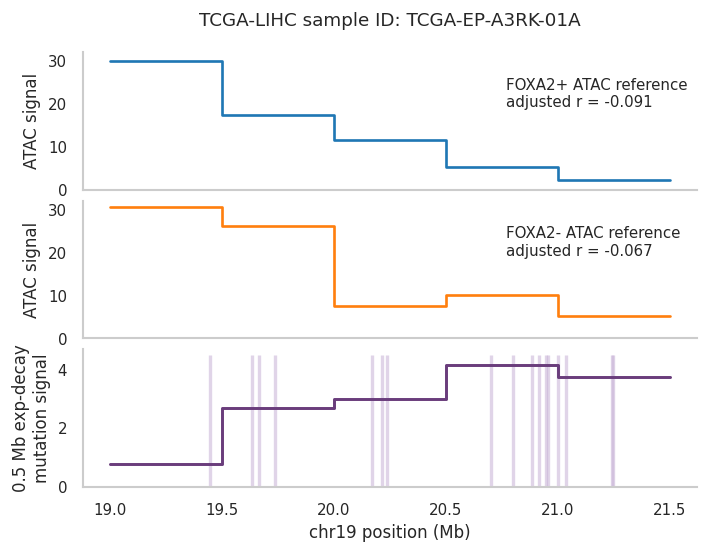

PosixPath('/home/lem/projects/mut-epi-origin/outputs/thesis/02_foxa2_epigenome_orientation/figures/04_selected_locus_foxa2_atac_with_sample_exp_decay_mutations.png')

In [5]:
sample = 'TCGA-EP-A3RK-01A'
chrom = 'chr19'
region_start = 19_000_000
region_end = 21_500_000
bin_size = 500_000
exp_decay_bp = 200_000
exp_max_distance_bp = 1_000_000

plot_df = atac_bins[
    (atac_bins['chrom'] == chrom)
    & (atac_bins['start'] >= region_start)
    & (atac_bins['end'] <= region_end)
].copy()
plot_df['midpoint'] = (plot_df['start'] + plot_df['end']) / 2
plot_df['midpoint_mb'] = plot_df['midpoint'] / 1_000_000
plot_df = plot_df.rename(columns={
    'foxa2_normal_like_atac': 'FOXA2+ ATAC',
    'foxa2_abnormal_like_atac': 'FOXA2- ATAC',
})

mutation_path = ROOT / 'data/raw/mutations/lihc_snv_mutation_table.tsv'
mutations = pd.read_csv(
    mutation_path,
    sep='\t',
    header=None,
    names=['chrom', 'start', 'end', 'sample', 'ref', 'alt', 'cancer_type'],
    usecols=[0, 1, 2, 3, 4, 5, 6],
    dtype={'chrom': str, 'sample': str, 'ref': str, 'alt': str, 'cancer_type': str},
    low_memory=False,
)
mutations['start'] = pd.to_numeric(mutations['start'], errors='coerce')
mutations['end'] = pd.to_numeric(mutations['end'], errors='coerce')
mutations = mutations.dropna(subset=['start', 'end'])
region_mut = mutations[
    (mutations['chrom'] == chrom)
    & (mutations['sample'] == sample)
    & (mutations['start'] >= region_start - exp_max_distance_bp)
    & (mutations['start'] < region_end + exp_max_distance_bp)
].copy()

signals = []
for midpoint in plot_df['midpoint']:
    distances = np.abs(region_mut['start'].to_numpy(dtype=float) - midpoint)
    distances = distances[distances <= exp_max_distance_bp]
    signals.append(float(np.exp(-distances / exp_decay_bp).sum()))
plot_df['sample_exp_decay_mutation_signal'] = signals
plot_df['n_mutations_used_for_decay_window'] = len(region_mut)
plot_df.to_csv(DATA_DIR / 'selected_locus_foxa2_atac_and_sample_exp_decay_profile.csv', index=False)

region_mut_display = region_mut[(region_mut['start'] >= region_start) & (region_mut['start'] < region_end)].copy()
region_mut_display['position_mb'] = region_mut_display['start'] / 1_000_000
region_mut_display.to_csv(DATA_DIR / 'selected_locus_mutation_positions.csv', index=False)

summary = locus_summary.iloc[0].copy()
summary['region'] = f'{chrom}:{region_start}-{region_end}'
summary['region_mutation_count'] = len(region_mut_display)
summary['decay_window_mutation_count'] = len(region_mut)
pd.DataFrame([summary]).to_csv(DATA_DIR / 'selected_locus_illustrative_sample_score_summary.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(6.6, 4.7), sharex=True, gridspec_kw={'hspace': 0.08})
x_edges = np.r_[plot_df['start'].to_numpy() / 1_000_000, plot_df['end'].iloc[-1] / 1_000_000]
plus_y = np.r_[plot_df['FOXA2+ ATAC'].to_numpy(), plot_df['FOXA2+ ATAC'].iloc[-1]]
minus_y = np.r_[plot_df['FOXA2- ATAC'].to_numpy(), plot_df['FOXA2- ATAC'].iloc[-1]]
mut_y = np.r_[plot_df['sample_exp_decay_mutation_signal'].to_numpy(), plot_df['sample_exp_decay_mutation_signal'].iloc[-1]]

axes[0].step(x_edges, plus_y, where='post', color='#1f77b4', linewidth=1.6)
axes[1].step(x_edges, minus_y, where='post', color='#ff7f0e', linewidth=1.6)
axes[2].step(x_edges, mut_y, where='post', color='#6a3d7c', linewidth=1.6)
for xpos in region_mut_display['position_mb']:
    axes[2].vlines(xpos, 0, 4.5, color='#c7b2d6', linewidth=2.0, alpha=0.55, zorder=1)
axes[2].step(x_edges, mut_y, where='post', color='#6a3d7c', linewidth=1.6, zorder=2)

axes[0].set_ylabel('ATAC signal')
axes[1].set_ylabel('ATAC signal')
axes[2].set_ylabel('0.5 Mb exp-decay\nmutation signal')
axes[2].set_xlabel('chr19 position (Mb)')
axes[0].set_ylim(0, 32)
axes[1].set_ylim(0, 32)
axes[2].set_ylim(0, 4.7)
axes[0].text(0.69, 0.70, 'FOXA2+ ATAC reference\nadjusted r = -0.091', transform=axes[0].transAxes, ha='left', va='center', fontsize=9)
axes[1].text(0.69, 0.70, 'FOXA2- ATAC reference\nadjusted r = -0.067', transform=axes[1].transAxes, ha='left', va='center', fontsize=9)
axes[0].set_title(f'TCGA-LIHC sample ID: {sample}', pad=16)
axes[2].set_xlim(18.88, 21.62)
axes[2].set_xticks(np.arange(19.0, 21.6, 0.5))
for ax in axes:
    ax.grid(False)
    sns.despine(ax=ax)
fig.tight_layout()
save_and_show(fig, FIG_DIR / '04_selected_locus_foxa2_atac_with_sample_exp_decay_mutations.png')
